In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterSampler, ParameterGrid
# from dwsim_pilot_parametric_study import parametric_study
from scipy.special import iv

In [2]:
import locale
import matplotlib as mpl

locale.setlocale(locale.LC_NUMERIC, "pt_BR.utf8")
locale.setlocale(locale.LC_TIME, "pt_BR.utf8")
plt.rcParams['axes.formatter.use_locale'] = True

# Configure text rendering to match your document's LaTeX engine
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex", 
    "font.family": "serif",      # Matches standard LaTeX Computer Modern Font
    "text.usetex": True,         # Forces LaTeX text processing
    "pgf.rcfonts": False,        # Ignores default Python fonts
})

In [3]:
cols_F = ['F_Methane_out_dwsim', 'F_Ethane_out_dwsim',
       'F_Propane_out_dwsim', 'F_N-butane_out_dwsim', 'F_N-pentane_out_dwsim',
       'F_N-hexane_out_dwsim', 'F_N-heptane_out_dwsim', 'F_N-octane_out_dwsim',
       'F_N-nonane_out_dwsim', 'F_N-decane_out_dwsim',
       'F_N-undecane_out_dwsim', 'F_N-dodecane_out_dwsim',
       'F_N-tridecane_out_dwsim', 'F_N-tetradecane_out_dwsim',
       'F_N-pentadecane_out_dwsim', 'F_N-hexadecane_out_dwsim',
       'F_N-heptadecane_out_dwsim', 'F_N-octadecane_out_dwsim',
       'F_N-nonadecane_out_dwsim', 'F_N-heneicosane_out_dwsim',
       'F_N-docosane_out_dwsim', 'F_N-tetracosane_out_dwsim',
       'F_N-pentacosane_out_dwsim', 'F_N-hexacosane_out_dwsim',
       'F_N-heptacosane_out_dwsim', 'F_N-octacosane_out_dwsim',
       'F_N-nonacosane_out_dwsim', 'F_N-eicosane_out_dwsim',
       'F_Water_out_dwsim', 'F_Hydrogen_out_dwsim',
       'F_Carbon monoxide_out_dwsim', 'F_Ethylene_out_dwsim',
       'F_Propylene_out_dwsim', 'F_1-butene_out_dwsim', 'F_1-hexene_out_dwsim',
       'F_1-heptene_out_dwsim', 'F_1-octene_out_dwsim', 'F_1-nonene_out_dwsim',
       'F_1-decene_out_dwsim', 'F_1-undecene_out_dwsim',
       'F_1-dodecene_out_dwsim', 'F_1-tetradecene_out_dwsim',
       'F_1-hexadecene_out_dwsim', 'F_1-octadecene_out_dwsim',
       'F_N-tricosane_out_dwsim', 'F_Triacontane_out_dwsim',
       'F_Hentriacontane_out_dwsim', 'F_Dotriacontane_out_dwsim',
       'F_Tritriacontane_out_dwsim', 'F_Tetratriacontane_out_dwsim',
       'F_Pentatriacontane_out_dwsim', 'F_Hexatriacontane_out_dwsim',
       'F_1-pentene_out_dwsim', 'F_1-Tridecene_out_dwsim',
       'F_1-Pentadecene_out_dwsim', 'F_1-Heptadecene_out_dwsim',
       'F_Carbon dioxide_out_dwsim']

In [4]:
n_carbons = {'F_Methane_out_dwsim': 1, 'F_Ethane_out_dwsim': 2,
       'F_Propane_out_dwsim': 3, 'F_N-butane_out_dwsim': 4, 'F_N-pentane_out_dwsim': 5,
       'F_N-hexane_out_dwsim': 6, 'F_N-heptane_out_dwsim': 7, 'F_N-octane_out_dwsim': 8,
       'F_N-nonane_out_dwsim': 9, 'F_N-decane_out_dwsim': 10,
       'F_N-undecane_out_dwsim': 11, 'F_N-dodecane_out_dwsim': 12,
       'F_N-tridecane_out_dwsim': 13, 'F_N-tetradecane_out_dwsim': 14,
       'F_N-pentadecane_out_dwsim': 15, 'F_N-hexadecane_out_dwsim': 16,
       'F_N-heptadecane_out_dwsim': 17, 'F_N-octadecane_out_dwsim': 18,
       'F_N-nonadecane_out_dwsim': 19, 'F_N-heneicosane_out_dwsim': 21,
       'F_N-docosane_out_dwsim': 22, 'F_N-tetracosane_out_dwsim': 24,
       'F_N-pentacosane_out_dwsim': 25, 'F_N-hexacosane_out_dwsim': 26,
       'F_N-heptacosane_out_dwsim': 27, 'F_N-octacosane_out_dwsim': 28,
       'F_N-nonacosane_out_dwsim': 29, 'F_N-eicosane_out_dwsim': 20,
       'F_Ethylene_out_dwsim': 2,
       'F_Propylene_out_dwsim': 3, 'F_1-butene_out_dwsim': 4, 'F_1-hexene_out_dwsim': 6,
       'F_1-heptene_out_dwsim': 7, 'F_1-octene_out_dwsim': 8, 'F_1-nonene_out_dwsim': 9,
       'F_1-decene_out_dwsim': 10, 'F_1-undecene_out_dwsim': 11,
       'F_1-dodecene_out_dwsim': 12, 'F_1-tetradecene_out_dwsim': 13,
       'F_1-hexadecene_out_dwsim': 16, 'F_1-octadecene_out_dwsim': 18,
       'F_N-tricosane_out_dwsim': 23, 'F_Triacontane_out_dwsim': 30,
       'F_Hentriacontane_out_dwsim': 31, 'F_Dotriacontane_out_dwsim': 32,
       'F_Tritriacontane_out_dwsim': 33, 'F_Tetratriacontane_out_dwsim': 34,
       'F_Pentatriacontane_out_dwsim': 35, 'F_Hexatriacontane_out_dwsim': 36,
       'F_1-pentene_out_dwsim': 5, 'F_1-Tridecene_out_dwsim': 13,
       'F_1-Pentadecene_out_dwsim': 15, 'F_1-Heptadecene_out_dwsim': 17,
        }

In [5]:
double_bond = {'F_Methane_out_dwsim': False,
 'F_Ethane_out_dwsim': False,
 'F_Propane_out_dwsim': False,
 'F_N-butane_out_dwsim': False,
 'F_N-pentane_out_dwsim': False,
 'F_N-hexane_out_dwsim': False,
 'F_N-heptane_out_dwsim': False,
 'F_N-octane_out_dwsim': False,
 'F_N-nonane_out_dwsim': False,
 'F_N-decane_out_dwsim': False,
 'F_N-undecane_out_dwsim': False,
 'F_N-dodecane_out_dwsim': False,
 'F_N-tridecane_out_dwsim': False,
 'F_N-tetradecane_out_dwsim': False,
 'F_N-pentadecane_out_dwsim': False,
 'F_N-hexadecane_out_dwsim': False,
 'F_N-heptadecane_out_dwsim': False,
 'F_N-octadecane_out_dwsim': False,
 'F_N-nonadecane_out_dwsim': False,
 'F_N-heneicosane_out_dwsim': False,
 'F_N-docosane_out_dwsim': False,
 'F_N-tetracosane_out_dwsim': False,
 'F_N-pentacosane_out_dwsim': False,
 'F_N-hexacosane_out_dwsim': False,
 'F_N-heptacosane_out_dwsim': False,
 'F_N-octacosane_out_dwsim': False,
 'F_N-nonacosane_out_dwsim': False,
 'F_N-eicosane_out_dwsim': False,
 'F_Ethylene_out_dwsim': True,
 'F_Propylene_out_dwsim': True,
 'F_1-butene_out_dwsim': True,
 'F_1-hexene_out_dwsim': True,
 'F_1-heptene_out_dwsim': True,
 'F_1-octene_out_dwsim': True,
 'F_1-nonene_out_dwsim': True,
 'F_1-decene_out_dwsim': True,
 'F_1-undecene_out_dwsim': True,
 'F_1-dodecene_out_dwsim': True,
 'F_1-tetradecene_out_dwsim': True,
 'F_1-hexadecene_out_dwsim': True,
 'F_1-octadecene_out_dwsim': True,
 'F_N-tricosane_out_dwsim': False,
 'F_Triacontane_out_dwsim': False,
 'F_Hentriacontane_out_dwsim': False,
 'F_Dotriacontane_out_dwsim': False,
 'F_Tritriacontane_out_dwsim': False,
 'F_Tetratriacontane_out_dwsim': False,
 'F_Pentatriacontane_out_dwsim': False,
 'F_Hexatriacontane_out_dwsim': False,
 'F_1-pentene_out_dwsim': True,
 'F_1-Tridecene_out_dwsim': True,
 'F_1-Pentadecene_out_dwsim': True,
 'F_1-Heptadecene_out_dwsim': True}

In [6]:
MM = {}
for key in n_carbons.keys():
    if double_bond[key]:
        MM[key] = 12 * n_carbons[key] + 2 * n_carbons[key]
    else:
        MM[key] = 12 * n_carbons[key] + 2 * n_carbons[key] + 2
MM['F_Carbon dioxide_out_dwsim'] = 44
MM['F_Water_out_dwsim'] = 18
MM['F_Hydrogen_out_dwsim'] = 2
MM['F_Carbon monoxide_out_dwsim'] = 28

In [7]:
cols_Fout_C1_C4 = [key for key, value in n_carbons.items() if value in range(1,5)]
cols_Fout_C5_C8 = [key for key, value in n_carbons.items() if value in range(5,9)]
cols_Fout_C9_C15 = [key for key, value in n_carbons.items() if value in range(9,16)]
cols_Fout_C16p = [key for key, value in n_carbons.items() if value in range(16,37)]
cols_Fout_C5p = [key for key, value in n_carbons.items() if value in range(5,37)]

In [8]:
MM_C1_C4 = {comp: MM[comp] for comp in cols_Fout_C1_C4}
MM_C5_C8 = {comp: MM[comp] for comp in cols_Fout_C5_C8}
MM_C9_C15 = {comp: MM[comp] for comp in cols_Fout_C9_C15}
MM_C16p = {comp: MM[comp] for comp in cols_Fout_C16p}
MM_C5p = {comp: MM[comp] for comp in cols_Fout_C5p}

In [9]:
def complete_data(data):
    data['H2_CO'] = data.F_H2_in / data.F_CO_in
    data['T (ºC)'] = data.T_K - 273.15
    data['P (bar)'] = data.P_Pa / 1e5
    data[r'$X_\mathrm{CO}$'] = (
        (data.F_CO_in - data['F_Carbon monoxide_out_dwsim']) / data.F_CO_in
    )
    data[r'$X_\mathrm{H_2}$'] = (
        (data.F_H2_in - data['F_Hydrogen_out_dwsim']) / data.F_H2_in
    )
    data[r'$\mathrm{v_{CO,in}}$ (L/min)'] =  1000 * 60 * data.F_CO_in * 8.314 * 273 / 1e5
    data[r'$\mathrm{v_{H_2,in}}$ (L/min)'] = 1000 * 60 * data.F_H2_in * 8.314 * 273 / 1e5
    
    Fout_C1_C4 = data[cols_Fout_C1_C4]
    Fout_C5_C8 = data[cols_Fout_C5_C8]
    Fout_C9_C15 = data[cols_Fout_C9_C15]
    Fout_C16p = data[cols_Fout_C16p]
    Fout_C5p = data[cols_Fout_C5p]
    
    mout_C1_C4 = Fout_C1_C4.mul(MM_C1_C4, axis = 'columns')
    mout_C5_C8 = Fout_C5_C8.mul(MM_C5_C8, axis = 'columns')
    mout_C9_C15 = Fout_C9_C15.mul(MM_C9_C15, axis = 'columns')
    mout_C16p = Fout_C16p.mul(MM_C16p, axis = 'columns')
    mout_C5p = Fout_C5p.mul(MM_C5p, axis = 'columns')
    
    data[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C1_C4.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C5_C8.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C9_C15.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C16p.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$)'] = mout_C5p.sum(axis = 'columns') * 86400 / 1000 # $\mathrm{kg~d^{-1}}$
    data[r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'] = data['F_Carbon dioxide_out_dwsim'] * 44 * 86400 / 1000
    data[r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)'] = data['F_Water_out_dwsim'] * 18 * 86400 / 1000
    
    data['C1_C4_sel'] = data[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C5_C8_sel'] = data[r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C9_C15_sel'] = data[r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['C16p_sel'] = data[r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['CO2_sel'] = data[r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    data['H2O_sel'] = data[r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)']/(
        data[[
            r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
            r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
        ]].sum(axis = 'columns')
    )
    return data

In [10]:
# Paths
dwsim_path = r"C:\Users\rafae\AppData\Local\DWSIM\\"
sim_path = r"C:\Users\rafae\Documents\Rafael Duarte\SAF_kinetics_paper_code_with_WGS\SAF_kinetics_paper_code_with_WGS\dwsim_pilot_model_parametric.dwxmz"

In [11]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 1), 
              'P_Pa'       : [20e5],
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [0.001, 2, 4, 10],
              'V_m3'       : [0.045],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.F_CO_in = F0 - parametric_data.F_H2_in
parametric_data['phi'] = parametric_data['phi_220C'] * ( 
        ( 493 / parametric_data['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data['T_K'] - 1/493 ) ) 
    ) ** (1/2)

parametric_data['eff'] = (
    iv(1, 2 * parametric_data['phi']) / 
    ( parametric_data['phi'] * iv(0,  2 * parametric_data['phi']) ) )

parametric_data = parametric_study(parametric_data, num_workers:=16, dwsim_path, sim_path)
parametric_data = complete_data(parametric_data)
parametric_data.to_pickle('parametric_data_dwsim_pilot.pkl')
parametric_data.to_excel('parametric_data_dwsim_pilot.ods')

In [12]:
parametric_data = pd.read_pickle('parametric_data_dwsim_pilot.pkl')
parametric_data = complete_data(parametric_data)

In [13]:
fig_path = '/home/rafael/GoogleDrive/uem/Doutorado/Tese/LaTeX_source_tese/figures/cinética_FTS/'
# fig_path = ''

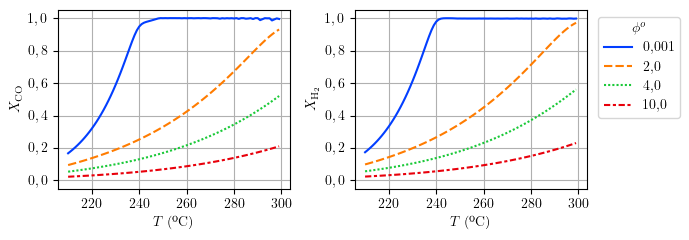

In [14]:
fig, ax = plt.subplots(1,2,figsize=(7,2.5))
sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$X_\mathrm{CO}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi^o$').remove()
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid('both')
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['H2_CO'] == 2)],
            x = 'T (ºC)', y = r'$X_\mathrm{H_2}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid('both')
ax[1].set_xlabel(r'$T$ (ºC)')

# 3. Grab the existing legend handles and text objects
handles, labels = ax[1].get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
localized_labels = [label.replace('.', ',') for label in labels]

ax[1].legend(handles=handles, labels=localized_labels, title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
fig_name = 'figure-X_pilot_phi.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [15]:
# smooth some noisy data
loc_noisy_data = ( (parametric_data.phi_220C == 0.001) & (parametric_data.T_K > 250 + 273.15) )

from sklearn.linear_model import LinearRegression
X = parametric_data.loc[loc_noisy_data, 'T (ºC)'].values.reshape(-1, 1)
y = parametric_data.loc[loc_noisy_data, r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'].values
model = LinearRegression().fit(X, y)
parametric_data.loc[loc_noisy_data, r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'] = model.predict(X)

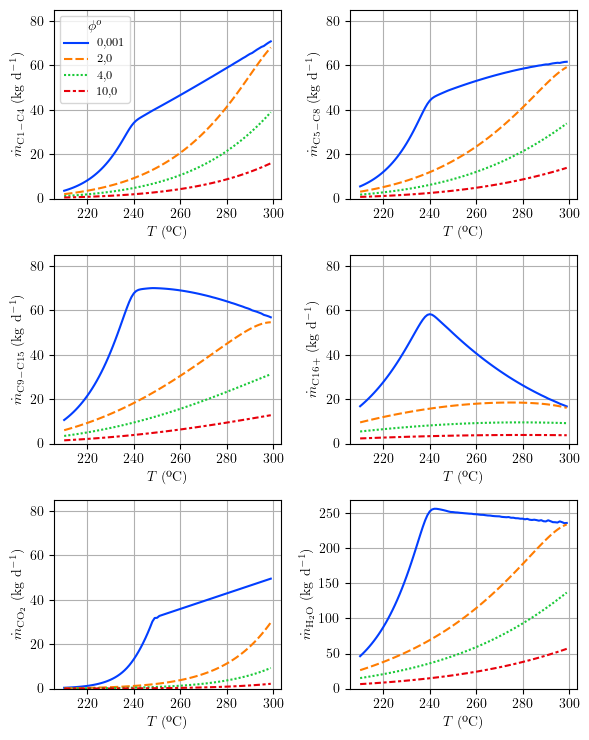

In [55]:
fig, ax = plt.subplots(3,2,figsize=(6,7.5))
ax = ax.flatten()

max_y = 85

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].grid('both')
ax[0].set_ylim(0, max_y)
ax[0].set_xlabel(r'$T$ (ºC)')
# 3. Grab the existing legend handles and text objects
handles, labels = ax[0].get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
localized_labels = [label.replace('.', ',') for label in labels]

ax[0].legend(handles=handles, labels=localized_labels, title = r'$\phi^o$', fontsize = 8.4, ncols = 1)

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$\phi^o$').remove()
ax[1].grid('both')
ax[1].set_ylim(0, max_y)
ax[1].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[2]
            )
ax[2].legend().remove()
ax[2].grid('both')
ax[2].set_ylim(0, max_y)
ax[2].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[3]
            )
ax[3].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[3].grid('both')
ax[3].set_ylim(0, max_y)
ax[3].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[4]
            )
ax[4].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[4].grid('both')
ax[4].set_ylim(0, max_y)
ax[4].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[5]
            )
ax[5].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[5].grid('both')
ax[5].set_ylim(0, None)
ax[5].set_xlabel(r'$T$ (ºC)')

plt.tight_layout()
fig_name = 'figure-m_out_pilot.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [17]:
parametric_data.columns

Index(['F_CO_in', 'F_H2_in', 'P_Pa', 'T_K', 'V_m3', 'phi_220C', 'phi', 'eff',
       'Reactor Energy Flow (kW)', 'F_Methane_out_dwsim', 'F_Ethane_out_dwsim',
       'F_Propane_out_dwsim', 'F_N-butane_out_dwsim', 'F_N-pentane_out_dwsim',
       'F_N-hexane_out_dwsim', 'F_N-heptane_out_dwsim', 'F_N-octane_out_dwsim',
       'F_N-nonane_out_dwsim', 'F_N-decane_out_dwsim',
       'F_N-undecane_out_dwsim', 'F_N-dodecane_out_dwsim',
       'F_N-tridecane_out_dwsim', 'F_N-tetradecane_out_dwsim',
       'F_N-pentadecane_out_dwsim', 'F_N-hexadecane_out_dwsim',
       'F_N-heptadecane_out_dwsim', 'F_N-octadecane_out_dwsim',
       'F_N-nonadecane_out_dwsim', 'F_N-heneicosane_out_dwsim',
       'F_N-docosane_out_dwsim', 'F_N-tetracosane_out_dwsim',
       'F_N-pentacosane_out_dwsim', 'F_N-hexacosane_out_dwsim',
       'F_N-heptacosane_out_dwsim', 'F_N-octacosane_out_dwsim',
       'F_N-nonacosane_out_dwsim', 'F_N-eicosane_out_dwsim',
       'F_Water_out_dwsim', 'F_Hydrogen_out_dwsim',
       'F_C

In [18]:
parametric_data['T (ºC)'].unique()

array([210., 211., 212., 213., 214., 215., 216., 217., 218., 219., 220.,
       221., 222., 223., 224., 225., 226., 227., 228., 229., 230., 231.,
       232., 233., 234., 235., 236., 237., 238., 239., 240., 241., 242.,
       243., 244., 245., 246., 247., 248., 249., 250., 251., 252., 253.,
       254., 255., 256., 257., 258., 259., 260., 261., 262., 263., 264.,
       265., 266., 267., 268., 269., 270., 271., 272., 273., 274., 275.,
       276., 277., 278., 279., 280., 281., 282., 283., 284., 285., 286.,
       287., 288., 289., 290., 291., 292., 293., 294., 295., 296., 297.,
       298., 299.])

In [19]:
parametric_data[r'$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$)'] = (
    parametric_data[[r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)']].sum(axis = 'columns')
)

In [20]:
parametric_data.loc[(parametric_data.phi_220C == 4) & (parametric_data['T (ºC)'] == 250),
    [r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)',
       r'$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$)',
     r'$X_\mathrm{CO}$', r'$X_\mathrm{H_2}$'
    ]
    ]

,$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$),$\dot{m}_\mathrm{HCs}$ ($\mathrm{kg~d^{-1}}$),$X_\mathrm{CO}$,$X_\mathrm{H_2}$
162,7.204949,8.74534,12.373021,8.789919,29.908279,0.752036,46.456762,37.113228,0.169394,0.17985


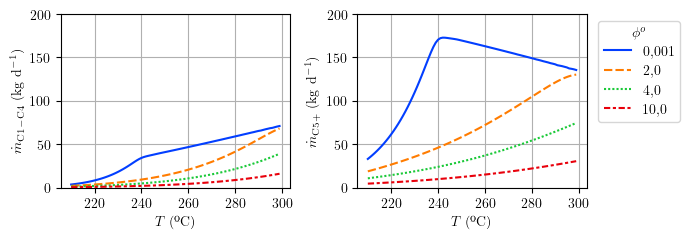

In [21]:
fig, ax = plt.subplots(1,2,figsize=(7,2.5))

max_y = 200

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi^o$').remove()
ax[0].grid('both')
ax[0].set_ylim(0, max_y)
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].grid('both')
ax[1].set_ylim(0, max_y)
ax[1].set_xlabel(r'$T$ (ºC)')

# 3. Grab the existing legend handles and text objects
handles, labels = ax[1].get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
localized_labels = [label.replace('.', ',') for label in labels]

ax[1].legend(handles=handles, labels=localized_labels, title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
fig_name = 'figure-m_out_pilot_C5p.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

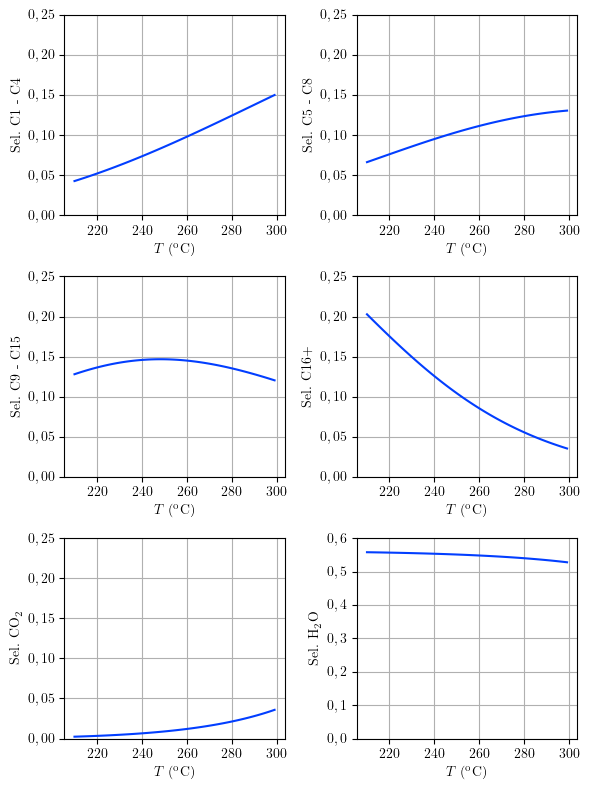

In [22]:
fig, ax = plt.subplots(3,2,figsize=(6,8))
ax = ax.flatten()

max_y = 0.25

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C1_C4_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[0], palette = 'bright',
            )
# ax[0].legend(title = r'$\phi^o$')
ax[0].legend().remove()
ax[0].set_ylabel('Sel. C1 - C4')
ax[0].set_ylim(0, max_y)
ax[0].grid('both')
ax[0].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C5_C8_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[1], palette = 'bright',
            )
# ax[0].legend(title = r'$\phi^o$')
ax[1].legend().remove()
ax[1].set_ylabel('Sel. C5 - C8')
ax[1].set_ylim(0, max_y)
ax[1].grid('both')
ax[1].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C9_C15_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[2], palette = 'bright',
            )
ax[2].legend().remove()
ax[2].set_ylabel('Sel. C9 - C15')
ax[2].set_ylim(0, max_y)
ax[2].grid('both')
ax[2].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C16p_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[3], palette = 'bright',
            )
ax[3].legend().remove()
ax[3].set_ylabel('Sel. C16+')
ax[3].set_ylim(0, max_y)
ax[3].grid('both')
ax[3].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'CO2_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[4], palette = 'bright',
            )
ax[4].legend().remove()
ax[4].set_ylabel(r'Sel. $\mathrm{CO_2}$')
ax[4].set_ylim(0, max_y)
ax[4].grid('both')
ax[4].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'H2O_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[5], palette = 'bright',
            )
ax[5].legend().remove()
ax[5].set_ylabel(r'Sel. $\mathrm{H_2O}$')
ax[5].set_ylim(0, 0.6)
ax[5].grid('both')
ax[5].set_xlabel(r'$T$ ($\mathrm{^o}$C)')

plt.tight_layout()
fig_name = 'figure-sel_pilot.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [23]:
Ri = ( 45.1 / 2 ) / 1000 # m
Re = ( ( 45.1 + 3.2 ) / 2 ) / 1000 # m

In [24]:
V = 45 / 1000 # m³

In [25]:
L = V / ( np.pi * Ri ** 2 )

In [26]:
L

28.168877986382718

In [27]:
A = 2 * np.pi * Re * L # m²

In [28]:
A

4.274315268853152

In [29]:
delta_T = 20 #K

In [30]:
parametric_data[r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$'] = - parametric_data['Reactor Energy Flow (kW)'] * 1000 / ( A * delta_T )

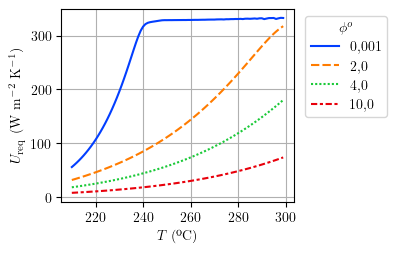

In [31]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(data = parametric_data,
            x = 'T (ºC)', y = r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax
            )
ax.grid('both')
ax.set_xlabel(r'$T$ (ºC)')
# 3. Grab the existing legend handles and text objects
handles, labels = ax.get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
localized_labels = [label.replace('.', ',') for label in labels]

ax.legend(handles=handles, labels=localized_labels, title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))

fig_name = 'figure_U_req.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [32]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid_P = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 20), 
              'P_Pa'       : np.arange(5e5, 35e5, 1e5),
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [4],
              'V_m3'       : [0.045],
             }

parametric_data_P = pd.DataFrame(ParameterGrid(param_grid_P))
parametric_data_P.F_CO_in = F0 - parametric_data_P.F_H2_in
parametric_data_P['phi'] = parametric_data_P['phi_220C'] * ( 
        ( 493 / parametric_data_P['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data_P['T_K'] - 1/493 ) ) 
    ) ** (1/2)
parametric_data_P['eff'] = (
    iv(1, 2 * parametric_data_P['phi']) / 
    ( parametric_data_P['phi'] * iv(0,  2 * parametric_data_P['phi']) ) )

parametric_data_P = parametric_study(parametric_data_P, num_workers:=16, dwsim_path, sim_path)
parametric_data_P = complete_data(parametric_data_P)
parametric_data_P.to_pickle('parametric_data_P_dwsim_pilot.pkl')
parametric_data_P.to_excel('parametric_data_P_dwsim_pilot.ods')

In [33]:
parametric_data_P = pd.read_pickle('parametric_data_P_dwsim_pilot.pkl')
parametric_data_P = complete_data(parametric_data_P)

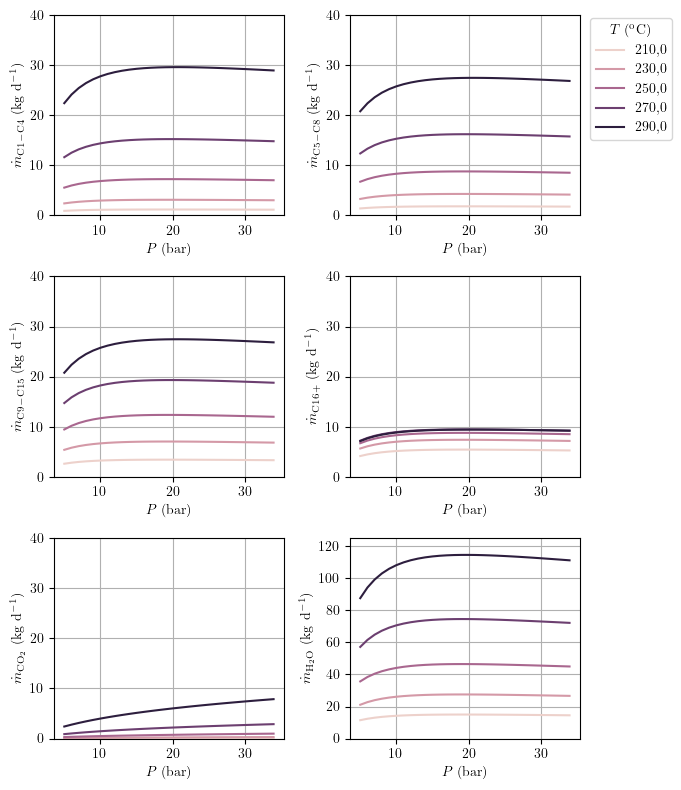

In [34]:
fig, ax = plt.subplots(3,2,figsize=(6,8))
ax = ax.flatten()

max_y = 40

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[0]
            )
ax[0].legend().remove()
ax[0].grid('both')
ax[0].set_ylim(0, max_y)
ax[0].set_xlabel(r'$P$ (bar)')

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[1]
            )
ax[1].legend().remove()
ax[1].grid('both')
ax[1].set_ylim(0, max_y)
ax[1].set_xlabel(r'$P$ (bar)')

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[2]
            )
ax[2].legend().remove()
ax[2].grid('both')
ax[2].set_ylim(0, max_y)
ax[2].set_xlabel(r'$P$ (bar)')

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[3]
            )
ax[3].legend().remove()
ax[3].grid('both')
ax[3].set_ylim(0, max_y)
ax[3].set_xlabel(r'$P$ (bar)')

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[4]
            )
ax[4].legend().remove()
ax[4].grid('both')
ax[4].set_ylim(0, max_y)
ax[4].set_xlabel(r'$P$ (bar)')

sns.lineplot(data = parametric_data_P,
            x = 'P (bar)', y = r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'T (ºC)', ax = ax[5]
            )
ax[5].legend().remove()
ax[5].grid('both')
ax[5].set_ylim(0, 125)
ax[5].set_xlabel(r'$P$ (bar)')

handles, labels = ax[1].get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
labels = [label.replace('.', ',') for label in labels]

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(1.06, 0.81), # Adjust 0.92 to move it up or down
           ncol=1, 
           frameon=True,
           title = r'$T$ ($\mathrm{^o}$C)',
          )

plt.tight_layout()
fig_name = 'figure-m_out_pilot_P.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [35]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid_V = {'T_K'      : np.arange(210 + 273.15, 270 + 273.15, 10), 
              'P_Pa'       : [20e5],
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [4],
              'V_m3'       : np.linspace(0.01, 0.6, 20)
             }

parametric_data_V = pd.DataFrame(ParameterGrid(param_grid_V))
parametric_data_V.F_CO_in = F0 - parametric_data_V.F_H2_in
parametric_data_V['phi'] = parametric_data_V['phi_220C'] * ( 
        ( 493 / parametric_data_V['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data_V['T_K'] - 1/493 ) ) 
    ) ** (1/2)
parametric_data_V['eff'] = (
    iv(1, 2 * parametric_data_V['phi']) / 
    ( parametric_data_V['phi'] * iv(0,  2 * parametric_data_V['phi']) ) )

parametric_data_V = parametric_study(parametric_data_V, num_workers:=16, dwsim_path, sim_path)
parametric_data_V = complete_data(parametric_data_V)
parametric_data_V.to_pickle('parametric_data_V_dwsim_pilot.pkl')
parametric_data_V.to_excel('parametric_data_V_dwsim_pilot.ods')

In [36]:
parametric_data_V = pd.read_pickle('parametric_data_V_dwsim_pilot.pkl')
parametric_data_V = complete_data(parametric_data_V)

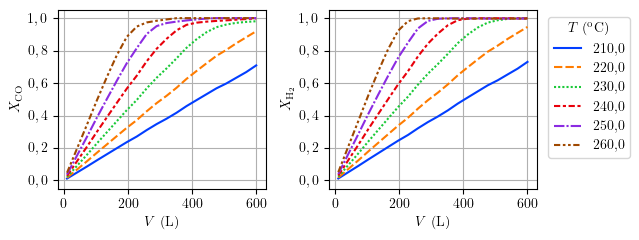

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(6.5,2.5))

parametric_data_V['V (L)'] = parametric_data_V['V_m3'] * 1000

sns.lineplot(data = parametric_data_V,
            x = 'V (L)', y = r'$X_\mathrm{CO}$', 
             hue = 'T (ºC)', style = 'T (ºC)', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$T$ (ºC)').remove()
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid('both')
ax[0].set_xlabel(r'$V$ (L)')

sns.lineplot(data = parametric_data_V,
            x = 'V (L)', y = r'$X_\mathrm{H_2}$', 
             hue = 'T (ºC)', style = 'T (ºC)', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$T$ ($\mathrm{^o}$C)', bbox_to_anchor=(1.02, 1))
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid('both')
ax[1].set_xlabel(r'$V$ (L)')

# 3. Grab the existing legend handles and text objects
handles, labels = ax[1].get_legend_handles_labels()

# 4. Replace the "." with "," in every label string
localized_labels = [label.replace('.', ',') for label in labels]

ax[1].legend(handles=handles, labels=localized_labels, title = r'$T$ ($\mathrm{^o}$C)', bbox_to_anchor=(1.02, 1))

plt.tight_layout()

fig_name = 'figure-V_vs_X_hue_T.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')
plt.show()

In [38]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid_200L = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 1), 
              'P_Pa'       : [20e5],
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [0.001, 2, 4, 10],
              'V_m3'       : [0.2],
             }

parametric_data_200L = pd.DataFrame(ParameterGrid(param_grid_200L))
parametric_data_200L.F_CO_in = F0 - parametric_data_200L.F_H2_in
parametric_data_200L['phi'] = parametric_data_200L['phi_220C'] * ( 
        ( 493 / parametric_data_200L['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data_200L['T_K'] - 1/493 ) ) 
    ) ** (1/2)
parametric_data_200L['eff'] = (
    iv(1, 2 * parametric_data_200L['phi']) / 
    ( parametric_data_200L['phi'] * iv(0,  2 * parametric_data_200L['phi']) ) )

parametric_data_200L = parametric_study(parametric_data_200L, num_workers:=16, dwsim_path, sim_path)
parametric_data_200L = complete_data(parametric_data_200L)
parametric_data_200L.to_pickle('parametric_data_200L_dwsim_pilot.pkl')
parametric_data_200L.to_excel('parametric_data_200L_dwsim_pilot.ods')

In [39]:
parametric_data_200L = pd.read_pickle('parametric_data_200L_dwsim_pilot.pkl')
parametric_data_200L = complete_data(parametric_data_200L)

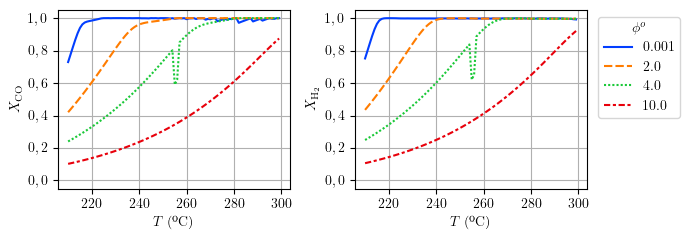

In [40]:
fig, ax = plt.subplots(1,2,figsize=(7,2.5))
sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$X_\mathrm{CO}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi^o$').remove()
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid('both')
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['H2_CO'] == 2)],
            x = 'T (ºC)', y = r'$X_\mathrm{H_2}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid('both')
ax[1].set_xlabel(r'$T$ (ºC)')

plt.tight_layout()
fig_name = 'figure-X_pilot_phi_200L.pdf'
plt.show()

In [41]:
# smooth some noisy data
loc_noisy_data = ( (parametric_data_200L.phi_220C == 0.001) & (parametric_data_200L.T_K > 250 + 273.15) )

from sklearn.linear_model import LinearRegression
X = parametric_data_200L.loc[loc_noisy_data, 'T (ºC)'].values.reshape(-1, 1)
y = parametric_data_200L.loc[loc_noisy_data, r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'].values
model = LinearRegression().fit(X, y)
parametric_data_200L.loc[loc_noisy_data, r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)'] = model.predict(X)

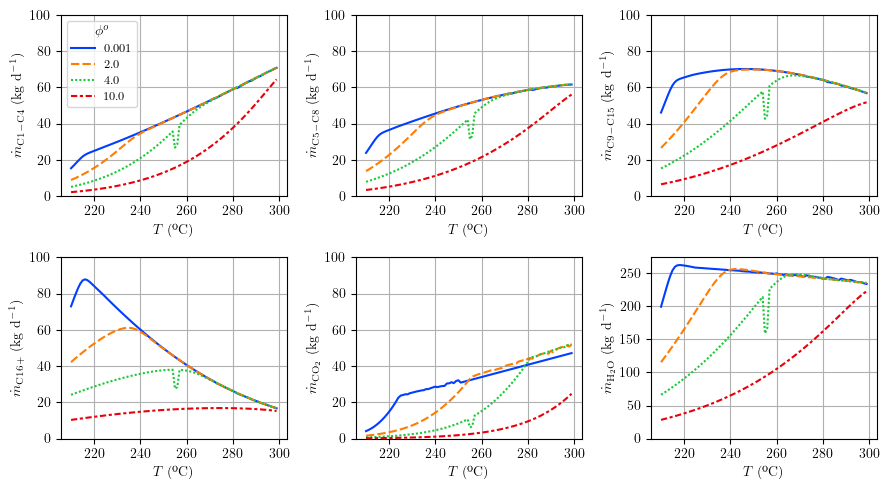

In [42]:
fig, ax = plt.subplots(2,3,figsize=(9,5))
ax = ax.flatten()

max_y = 100

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi^o$', fontsize = 8.4, ncols = 1)
ax[0].grid('both')
ax[0].set_ylim(0, max_y)
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C5-C8}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$\phi^o$').remove()
ax[1].grid('both')
ax[1].set_ylim(0, max_y)
ax[1].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[2]
            )
ax[2].legend().remove()
ax[2].grid('both')
ax[2].set_ylim(0, max_y)
ax[2].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C16+}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[3]
            )
ax[3].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[3].grid('both')
ax[3].set_ylim(0, max_y)
ax[3].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{CO_2}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[4]
            )
ax[4].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[4].grid('both')
ax[4].set_ylim(0, max_y)
ax[4].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{H_2O}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[5]
            )
ax[5].legend(title = r'$\phi^o$', fontsize = 9).remove()
ax[5].grid('both')
ax[5].set_ylim(0, None)
ax[5].set_xlabel(r'$T$ (ºC)')

plt.tight_layout()
fig_name = 'figure-m_out_pilot_200L.pdf'
plt.show()

In [43]:
parametric_data_200L.loc[parametric_data_200L['T (ºC)'] == 250][['phi_220C', r'$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)']]

,phi_220C,$\dot{m}_\mathrm{{C9-C15}}$ ($\mathrm{kg~d^{-1}}$)
160,0.001,70.034268
161,2.000,69.819108
162,4.000,53.088942
163,10.000,22.216646


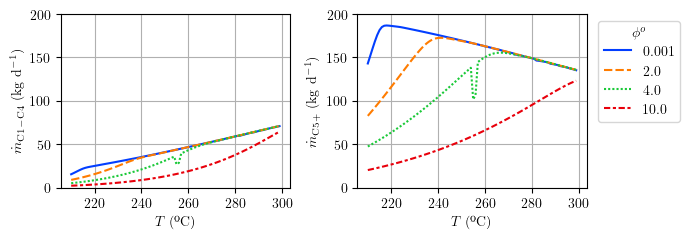

In [44]:
fig, ax = plt.subplots(1,2,figsize=(7,2.5))

max_y = 200

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C1-C4}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi^o$').remove()
ax[0].grid('both')
ax[0].set_ylim(0, max_y)
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$\dot{m}_\mathrm{{C5+}}$ ($\mathrm{kg~d^{-1}}$)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))
ax[1].grid('both')
ax[1].set_ylim(0, max_y)
ax[1].set_xlabel(r'$T$ (ºC)')

plt.tight_layout()
fig_name = 'figure-m_out_pilot_C5p_200L.pdf'
plt.show()

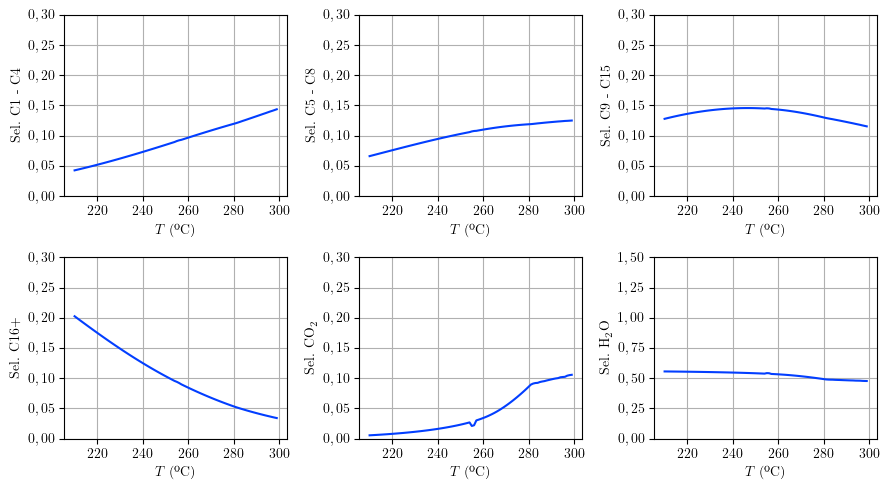

In [45]:
fig, ax = plt.subplots(2,3,figsize=(9,5))
ax = ax.flatten()

max_y = 0.3

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C1_C4_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[0], palette = 'bright',
            )
# ax[0].legend(title = r'$\phi^o$')
ax[0].legend().remove()
ax[0].set_ylabel('Sel. C1 - C4')
ax[0].set_ylim(0, max_y)
ax[0].grid('both')
ax[0].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C5_C8_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[1], palette = 'bright',
            )
# ax[0].legend(title = r'$\phi^o$')
ax[1].legend().remove()
ax[1].set_ylabel('Sel. C5 - C8')
ax[1].set_ylim(0, max_y)
ax[1].grid('both')
ax[1].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C9_C15_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[2], palette = 'bright',
            )
ax[2].legend().remove()
ax[2].set_ylabel('Sel. C9 - C15')
ax[2].set_ylim(0, max_y)
ax[2].grid('both')
ax[2].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C16p_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[3], palette = 'bright',
            )
ax[3].legend().remove()
ax[3].set_ylabel('Sel. C16+')
ax[3].set_ylim(0, max_y)
ax[3].grid('both')
ax[3].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'CO2_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[4], palette = 'bright',
            )
ax[4].legend().remove()
ax[4].set_ylabel(r'Sel. $\mathrm{CO_2}$')
ax[4].set_ylim(0, max_y)
ax[4].grid('both')
ax[4].set_xlabel(r'$T$ (ºC)')

sns.lineplot(data = parametric_data_200L.loc[(parametric_data_200L['P (bar)'] == 20) & (parametric_data_200L['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'H2O_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[5], palette = 'bright',
            )
ax[5].legend().remove()
ax[5].set_ylabel(r'Sel. $\mathrm{H_2O}$')
ax[5].set_ylim(0, 1.5)
ax[5].grid('both')
ax[5].set_xlabel(r'$T$ (ºC)')

plt.tight_layout()
fig_name = 'figure-sel_pilot_200L.pdf'
plt.show()

In [46]:
Ri = ( 45.1 / 2 ) / 1000 # m
Re = ( ( 45.1 + 3.2 ) / 2 ) / 1000 # m

In [47]:
V = 200 / 1000 # m³

In [48]:
L = V / ( np.pi * Ri ** 2 )

In [49]:
L

125.19501327281209

In [50]:
A = 2 * np.pi * Re * L # m²

In [51]:
A

18.996956750458455

In [52]:
delta_T = 20 #K

In [53]:
parametric_data_200L[r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$'] = - parametric_data_200L['Reactor Energy Flow (kW)'] * 1000 / ( A * delta_T )

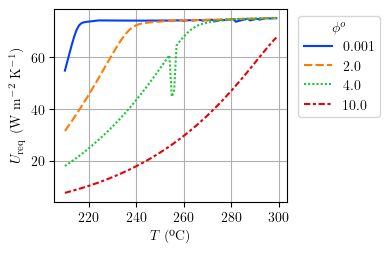

In [54]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(data = parametric_data_200L,
            x = 'T (ºC)', y = r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax
            )
ax.grid('both')
ax.legend(title = r'$\phi^o$', bbox_to_anchor=(1.02, 1))
ax.set_xlabel(r'$T$ (ºC)')

plt.show()